**NOTE:** Some variable names differ from those used in the main text, 
reflecting terminology changes made during the course of the study:
- 'fold' -> 'lineage'
- 'NONE' -> 'base seed'
- 'ALL' -> 'full network'

Each enzyme-gated network expansion run records iterations of network expansion as follows:
- cumiter: Tracks all individual expansion steps, including both lineage addition steps and the resulting standard network expansion steps
- folditer: Groups each lineage addition and the subsequent network expansion into a single unit; corresponds to a metabolic stage

In [1]:
from utils import*

In [2]:
# from Leave-One-Out analysis

group1 = ['2005', '4952', '184', '325', '3016', '2003', '2002', '7523', '328', '875', '602', '2486', '212', '4011', '7574', '218', '2004', '304', '7584', '206', '4953', '1', '3997', '7577', '148', '7501', '7579', '2007', '253', '7544', '101', '297', '327', '330', '141', '109', '2492']
first10 = ['2005', '4952', '325', '2003', '2002', '602', '218', '206', '4953', '2007']

In [3]:
# NONE 1000 runs

# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_folditer_NONE.csv', index_col=0)
# df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)
# df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_folditer_NONE.csv', index_col=0)
# df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_folditer_NONE.csv', index_col=0)

# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [4]:
rns_scope = list(df_rns_folditer[df_rns_folditer.columns[0]].keys())
len(rns_scope)

7678

# Find fastest & slowset runs

In [5]:
fo2cpds_list = []
for run in df_cpds_folditer.columns:
    fo2cpds = {}
    for c, order in df_cpds_folditer[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list.append(fo2cpds)
    
fo2cpdNum_list = []
for run in fo2cpds_list:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list.append(fo2cpdNum)

In [6]:
# fastest run

max_area = [0, 0]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
print(max_area)
print(f"fastest seed: {df_cpds_folditer.columns[max_area[0]]}")

[257, 895196]
fastest seed: 37860


In [7]:
# slowest run

min_area = [0, 100000000]
index = 0
for run in fo2cpdNum_list:
    area = sum(run.values())
    if area < min_area[1]:
        min_area = [index, area]
    index += 1
print(min_area)
print(f"slowest seed: {df_cpds_folditer.columns[min_area[0]]}")

[453, 845857]
slowest seed: 46652


In [8]:
# ATP pre-exp fastest run
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-09-27_13-49-38_no_lookahead_preExpansion_C00002_37860.pkl.gz')

### x = cumiter

612
851


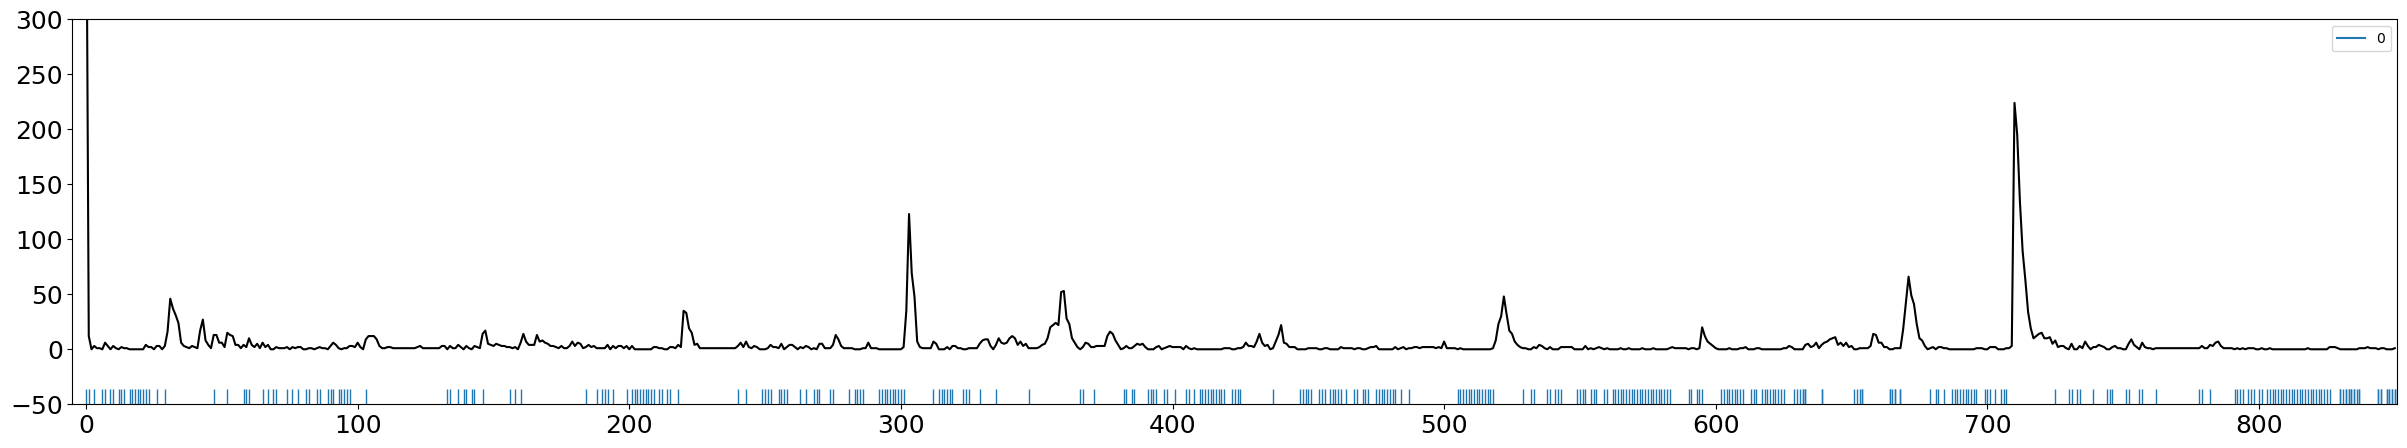

In [9]:
cumiter2cpd = {}
for c, order in result.cpds_cumiter.items():
    if order not in cumiter2cpd.keys():
        cumiter2cpd[order] = [c]
    else:
        cumiter2cpd[order].append(c)
print(len(cumiter2cpd))

cumiter2cpdNum = {}
for fold in cumiter2cpd.keys():
    cumiter2cpdNum[fold] = len(cumiter2cpd[fold])

cumiter2cpdNumFull = {}
for i in range(0, max(cumiter2cpd.keys())):
    if i not in cumiter2cpdNum.keys():
        cumiter2cpdNumFull[i] = 0
    else:
        cumiter2cpdNumFull[i] = cumiter2cpdNum[i]
print(len(cumiter2cpdNumFull))

plt.figure(figsize=(30, 5))
plt.plot(cumiter2cpdNumFull.values(), color='k')

# plot where fold injections happen
sns.rugplot(result.folds_cumiter.values(), height=0.04, color='blue')  # double fold injection

plt.xlim([-5, len(cumiter2cpdNumFull)])
plt.ylim([-50, 300])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
# plt.savefig('cumiter_rugplot.svg', dpi=300, bbox_inches='tight')
plt.show()

## x = folditer

In [10]:
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
print(len(folditer2cpdNumFull))

# only 164 fold injection steps lead to new cpd discovery
# new rules are constantly discovered after each fold injection, but new cpd discovery is harder

164
361


In [11]:
folditer2folds = {}
for fold, folditer in result.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)
print(len(folditer2folds))
        
double_injection = []
triple_injection = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double_injection.append(i)
    if len(folds) == 3:
        triple_injection.append(i)
        
# extend end until all injections complete
for i in range(len(folditer2folds) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0
print(len(folditer2cpdNumFull))

# for the last 11 fold injections, we only discover redundant reactions (no new cpds)

372
372


In [12]:
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        print(folds)

['920', '378']
['4018', '7587']
['4033', '4052']
['184', '7544']
['278', '604']
['2010', '590']
['4953', '602']
['3321', '3323']
['4971', '4223']
['7546', '7507']
['806', '169']
['192', '228']
['306', '75']
['865', '3018']
['3269', '872']
['3500', '3304']
['3623', '7563']
['4048', '4028']
['7578', '3993']
['7601', '7602']
['4046', '4024']
['3843', '3456']
['702', '3339']
['3374', '144']


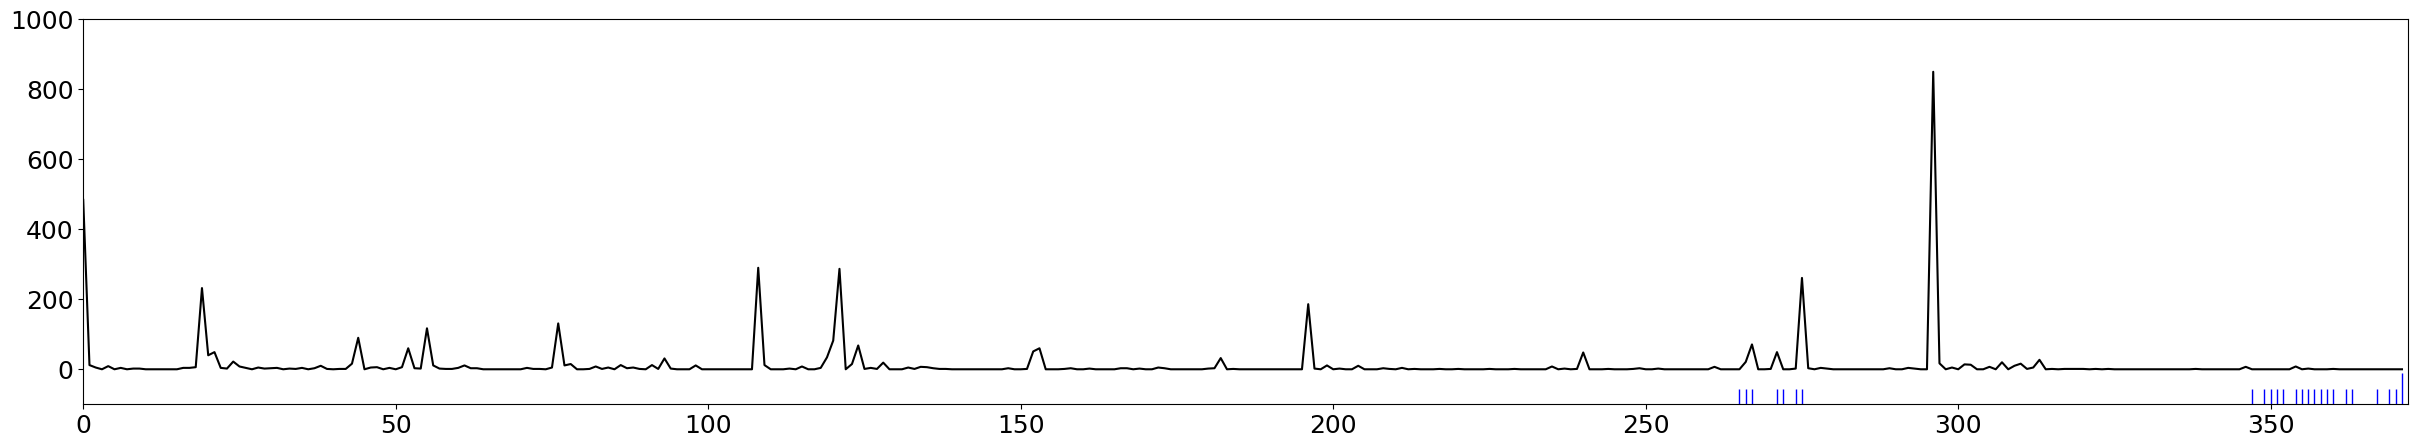

In [13]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
# plt.savefig('folditer_cpds.svg', dpi=300, bbox_inches='tight')
plt.show()

### annotate cpds

#### 1. custom set

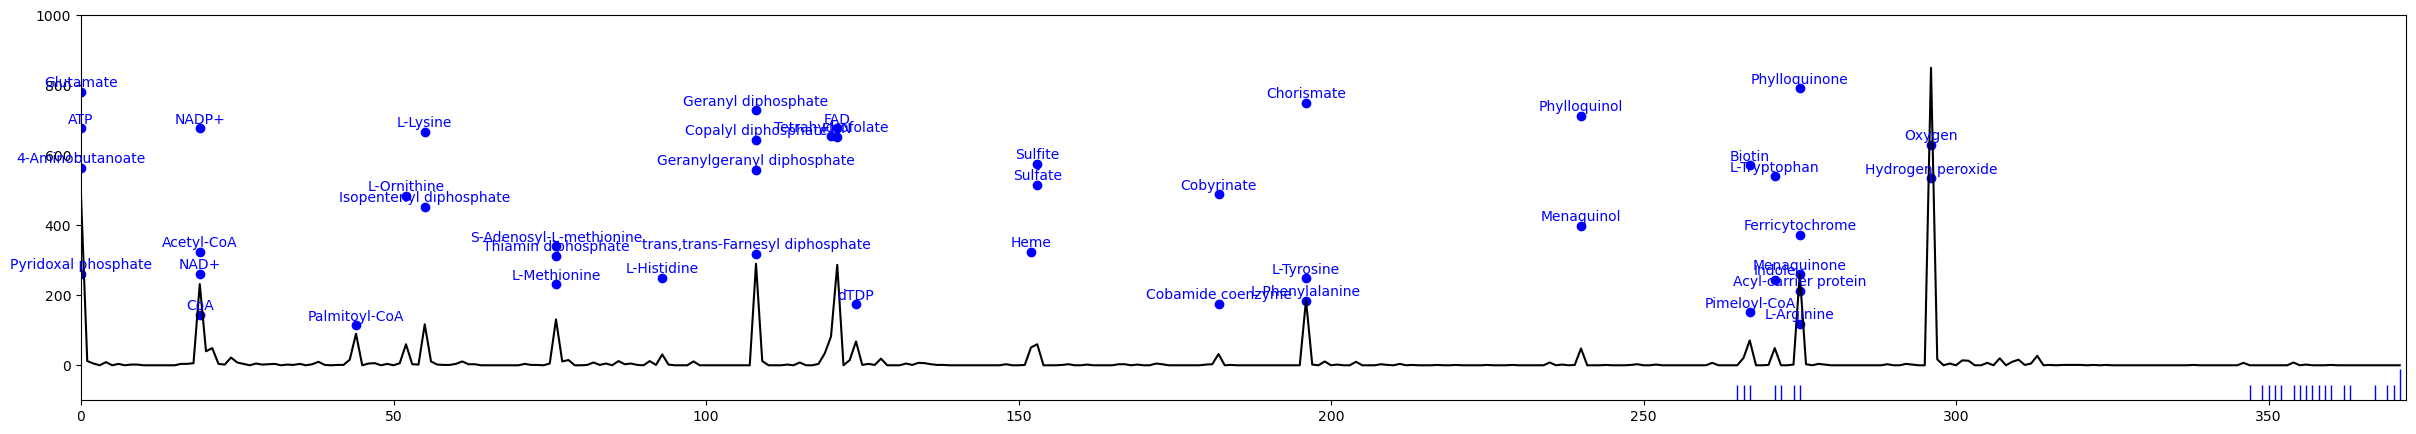

In [14]:
cpd2iter = {}
for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
# plt.savefig('folditer_cpds_annotated_2.svg', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# some peaks need further annotation?

cpd2rn = csv2dict('../data/assets/cpd2rn.csv')

In [16]:
for i, cpds in folditer2cpd.items():
    if len(cpds) > 30:
        print(i, len(cpds))

0 484
19 232
20 40
21 49
44 90
52 60
55 117
76 131
93 31
108 290
119 34
120 82
121 287
124 68
152 51
153 60
182 32
196 186
240 48
267 71
271 49
275 261
296 850


#### draw molecules at specific iteration

In [17]:
def get_kegg_compound_smiles(kegg_id):
    url = f'http://rest.kegg.jp/get/{kegg_id}/mol'
    response = requests.get(url)
    if response.status_code == 200:
        mol_data = response.text
        mol = Chem.MolFromMolBlock(mol_data)
        return mol
    else:
        raise ValueError(f"Error fetching data for {kegg_id}: {cpd2name.get(kegg_id, '')}")

def draw_multiple_molecules(molecules, mol_labels=None):
    img = Draw.MolsToGridImage(molecules, molsPerRow=10, subImgSize=(400, 400), legends=mol_labels, maxMols=200)
    display(img)

    with open('cpds.png', mode='wb') as f:
        f.write(img.data)
        
def drawMols(molecule_kegg_ids):
    molecules = []
    labels = []

    # from SMILES
    for kegg_id in molecule_kegg_ids:
        try:
            mol_kegg = get_kegg_compound_smiles(kegg_id)
            if mol_kegg:
                molecules.append(mol_kegg)
                labels.append(cpd2name[kegg_id])
        except ValueError as e:
            print(e)
            
    if molecules:
        draw_multiple_molecules(molecules, labels)

In [18]:
# drawMols(folditer2cpd[195])

#### 2. amino acids

C00037 Glycine
C00077 L-Ornithine
C00041 L-Alanine
C00097 L-Cysteine
C00049 L-Aspartate
C00025 L-Glutamate
C00079 L-Phenylalanine
C00135 L-Histidine
C00407 L-Isoleucine
C00047 L-Lysine
C00123 L-Leucine
C00073 L-Methionine
C00152 L-Asparagine
C00148 L-Proline
C00064 L-Glutamine
C00062 L-Arginine
C00065 L-Serine
C00188 L-Threonine
C00183 L-Valine
C00078 L-Tryptophan
C00082 L-Tyrosine


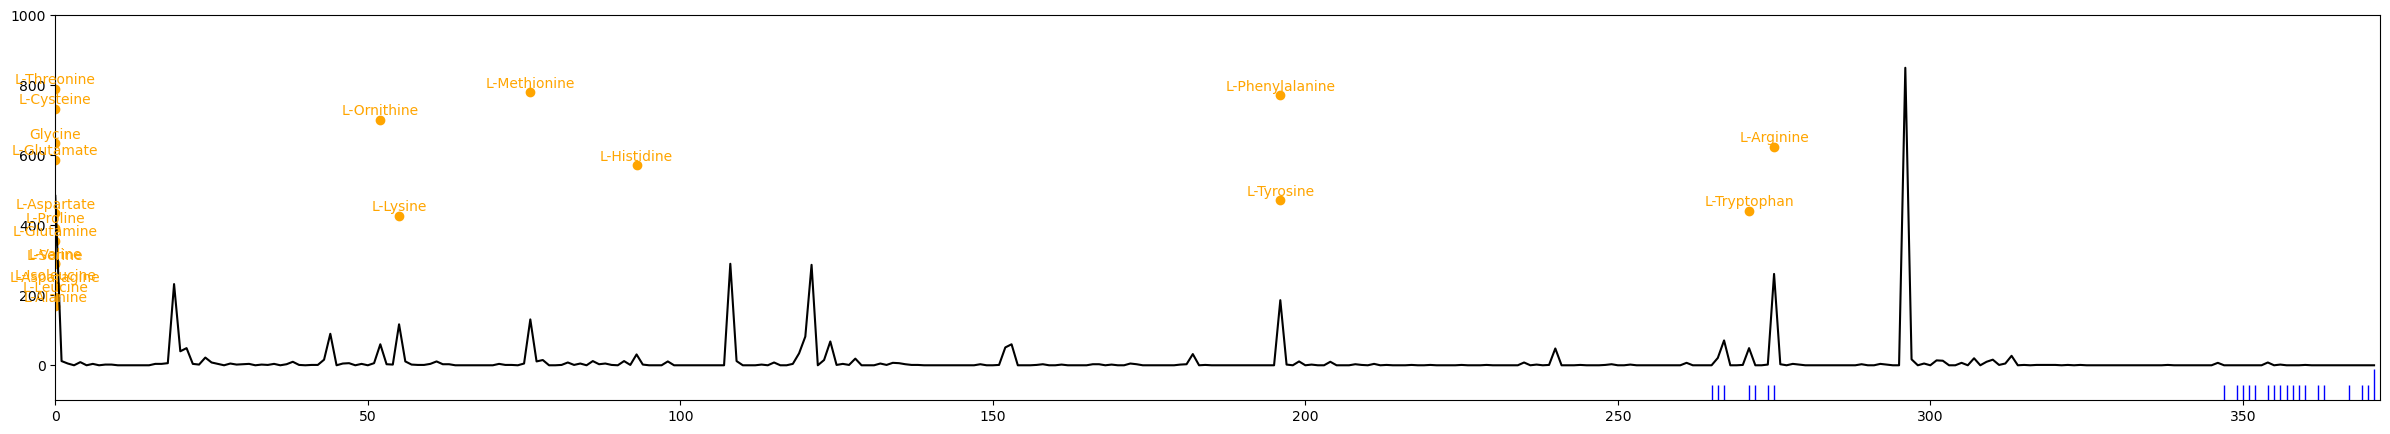

In [19]:
aa = ['C00037', 'C00077', 'C00041', 'C00097', 'C00049', 'C00025', 'C00079', 'C00135', 'C00407', 'C00047', 'C00123', 'C00073', 'C00152', 'C00148', 'C00064', 'C00062', 'C00065', 'C00188', 'C00183', 'C00078', 'C00082']
for a in aa:
    print(a, cpd2name[a])

aa2iter = {}
for a in aa:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if a == c:
                aa2iter[a] = folditer   
    
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

# Add annotations
for key, value in aa2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='orange')
    plt.scatter(value, position-5, color='orange')

plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
# plt.savefig('folditer_aas_annotated.svg', dpi=300, bbox_inches='tight')
plt.show()

#### 3. Z compounds

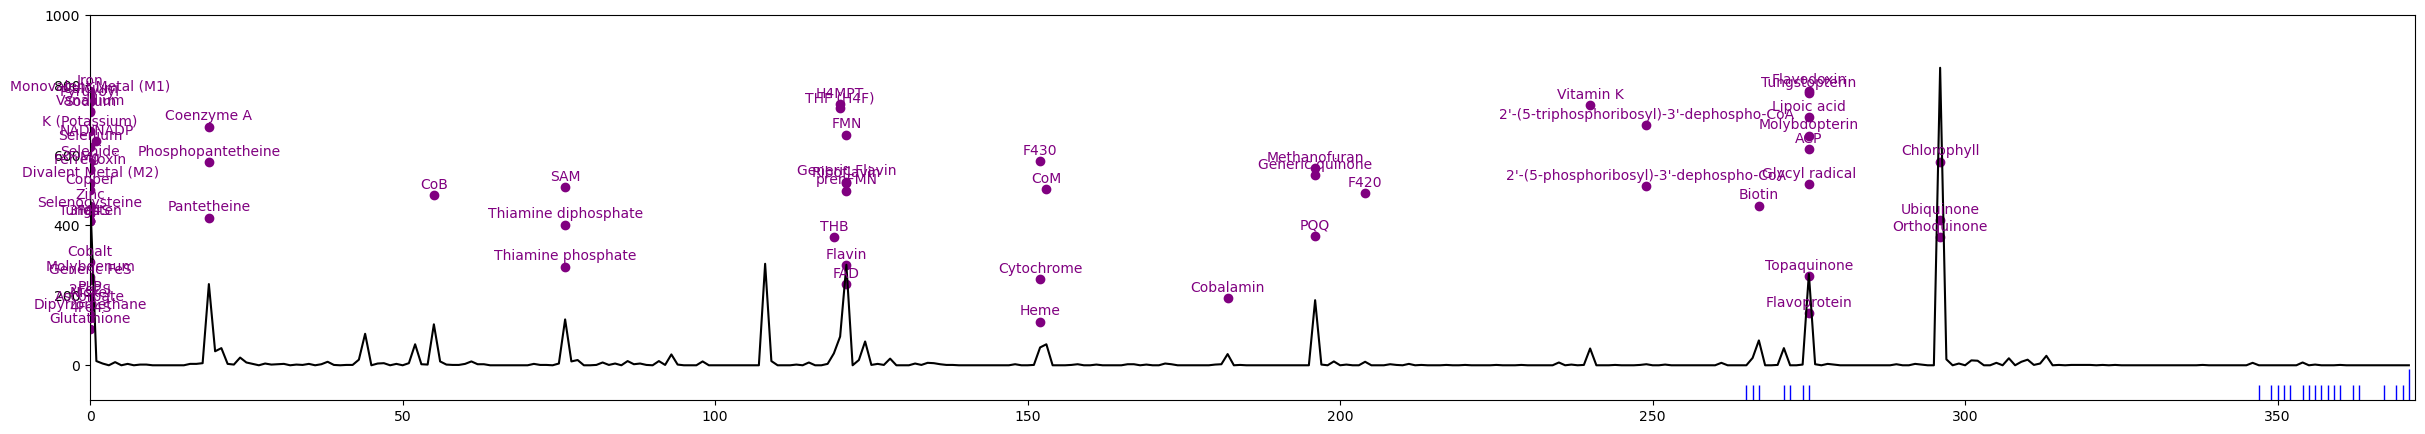

In [20]:
cpd2iterZ = {}

for folditer in folditer2cpd.keys():
    for c in folditer2cpd[folditer]:
        if c.startswith('Z'):
            cpd2iterZ[c] = folditer
            
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iterZ.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='purple')
    plt.scatter(value, position-10, color='purple')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
# plt.savefig('folditer_cpds_Z_annotated.svg.svg', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
for z in cpd2iterZ.keys():
    print(z, cpd2name[z])

Z00054 Zinc
Z00001 2Fe2S
Z00016 Ferredoxin
Z00062 Vanadium
Z00044 Selenocysteine
Z00035 PLP
Z00034 Nickel
Z00023 Glutathione
Z00060 Monovalent Metal (M1)
Z00033 Sodium
Z00026 K (Potassium)
Z00069 Divalent Metal (M2)
Z00042 Selenium
Z00002 4Fe4S
Z00063 Generic FeS
Z00029 Mg
Z00039 Pyruvoyl
Z00004 Ascorbate
Z00030 Mn
Z00053 Tungsten
Z00064 Molybdenum
Z00070 Copper
Z00043 Selenide
Z00055 Calcium
Z00067 3Fe4S
Z00015 Iron
Z00006 Cobalt
Z00056 Dipyrromethane
Z00032 NAD/NADP
Z00051 Coenzyme A
Z00037 Pantetheine
Z00038 Phosphopantetheine
Z00007 CoB
Z00047 Thiamine diphosphate
Z00041 SAM
Z00048 Thiamine phosphate
Z00045 THB
Z00046 THF (H4F)
Z00024 H4MPT
Z00017 Flavin
Z00057 prenFMN
Z00014 FMN
Z00040 Riboflavin
Z00021 Generic Flavin
Z00013 FAD
Z00025 Heme
Z00010 Cytochrome
Z00012 F430
Z00008 CoM
Z00009 Cobalamin
Z00036 PQQ
Z00022 Generic quinone
Z00028 Methanofuran
Z00011 F420
Z00050 Vitamin K
Z00066 2'-(5-triphosphoribosyl)-3'-dephospho-CoA
Z00071 2'-(5-phosphoribosyl)-3'-dephospho-CoA
Z00005 B

#### how many -CoA cpds are there?

In [22]:
CoA_cpds = set()
for cid, name in cpd2name.items():
    if 'CoA' in name:
        CoA_cpds.add(cid)
print(len(CoA_cpds))  # all CoA cpds in KEGG
print(len(CoA_cpds & set(df_cpds_folditer.index)))  # CoA cpds in our runs

400
216


In [23]:
for cpd, name in cpd2name.items():
    if 'CoA' in name:
        print(cpd, name)

C00010 CoA
C00024 Acetyl-CoA
C00040 Acyl-CoA
C00083 Malonyl-CoA
C00091 Succinyl-CoA
C00100 Propanoyl-CoA
C00136 Butanoyl-CoA
C00154 Palmitoyl-CoA
C00223 p-Coumaroyl-CoA
C00264 3-Oxoacyl-CoA
C00313 Oxalyl-CoA
C00323 Caffeoyl-CoA
C00332 Acetoacetyl-CoA
C00356 (S)-3-Hydroxy-3-methylglutaryl-CoA
C00406 Feruloyl-CoA
C00411 Sinapoyl-CoA
C00412 Stearoyl-CoA
C00510 Oleoyl-CoA
C00512 Benzoyl-CoA
C00527 Glutaryl-CoA
C00531 Itaconyl-CoA
C00540 Cinnamoyl-CoA
C00566 (3S)-Citryl-CoA
C00582 Phenylacetyl-CoA
C00605 2,3-Dehydroacyl-CoA
C00630 2-Methylpropanoyl-CoA
C00640 (3S)-3-Hydroxyacyl-CoA
C00658 trans-2,3-Dehydroacyl-CoA
C00683 (S)-Methylmalonyl-CoA
C00798 Formyl-CoA
C00827 Lactoyl-CoA
C00845 2-Furoyl-CoA
C00877 Crotonoyl-CoA
C00882 Dephospho-CoA
C00888 Pentanoyl-CoA
C00894 Propenoyl-CoA
C00904 Citramalyl-CoA
C00920 CoA-glutathione
C01011 (3S)-Citramalyl-CoA
C01033 2-Methylbutanoyl-CoA
C01063 Pimeloyl-CoA
C01086 (3R)-3-Hydroxyacyl-CoA
C01122 cis-2,3-Dehydroacyl-CoA
C01139 [Acetyl-CoA carboxylase]


### annotate group1 lineages

In [24]:
class2color = {'beta':'blue', 'alpha':'red', 'a+b':'green', 'a/b':'yellow', 'mixed':'purple', 'other':'grey'}

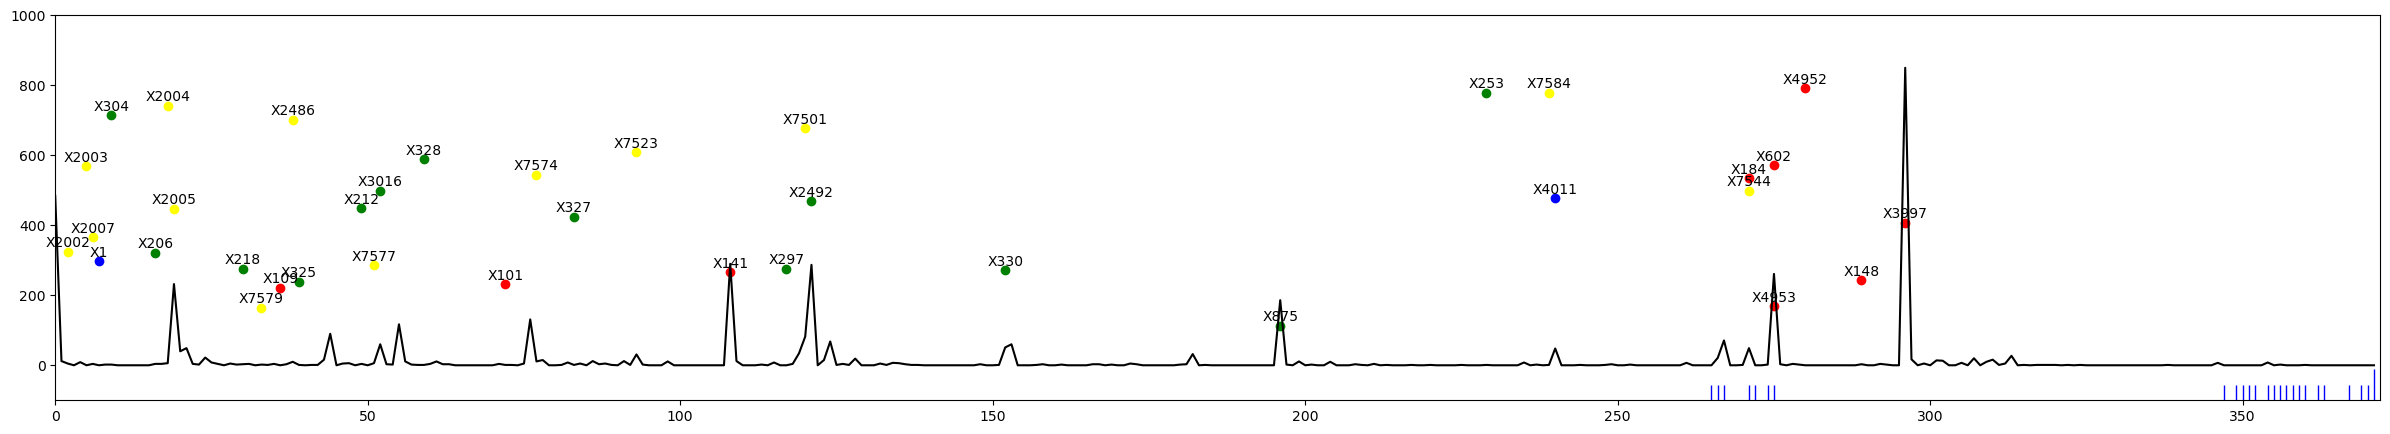

In [25]:
group12iter = {x:result.folds_folditer[x] for x in group1}

plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in group12iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='black')
    plt.scatter(value, position-5, color=class2color[x2class[key]])

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection

plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
# plt.savefig('folditer_group1_folds.svg', dpi=300, bbox_inches='tight')
plt.show()

# draw NONE with Figure 3 layout

In [26]:
df_cpds_folditer_NONE = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)

In [27]:
fo2cpds_list_NONE = []
for run in df_cpds_folditer_NONE.columns:
    fo2cpds = {}
    for c, order in df_cpds_folditer_NONE[run].items():
        if order not in fo2cpds.keys():
            fo2cpds[order] = [c]
        else:
            fo2cpds[order].append(c)
    fo2cpds_list_NONE.append(fo2cpds)
    
fo2cpdNum_list_NONE = []
for run in fo2cpds_list_NONE:                   
    fo2cpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cpdNum[i] = cumm
    fo2cpdNum_list_NONE.append(fo2cpdNum)

In [28]:
# fastest run

max_area = [0, 0]
index = 0
for run in fo2cpdNum_list_NONE:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
print(max_area)
print(f"fastest seed: {df_cpds_folditer_NONE.columns[max_area[0]]}")

[4, 793411]
fastest seed: 20023


In [29]:
# fastest run
result_NONE = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-10-02_17-59-41_no_lookahead_preExpansion_NONE_20023.pkl.gz')

In [30]:
folditer2cpd_NONE = {}
for c, order in result_NONE.cpds_folditer.items():
    if order not in folditer2cpd_NONE.keys():
        folditer2cpd_NONE[order] = [c]
    else:
        folditer2cpd_NONE[order].append(c)
print(len(folditer2cpd_NONE))

folditer2cpdNum_NONE = {}
for fold in folditer2cpd_NONE.keys():
    folditer2cpdNum_NONE[fold] = len(folditer2cpd_NONE[fold])

folditer2cpdNumFull_NONE = {}
for i in range(0, max(folditer2cpd_NONE.keys())):
    if i not in folditer2cpdNum_NONE.keys():
        folditer2cpdNumFull_NONE[i] = 0
    else:
        folditer2cpdNumFull_NONE[i] = folditer2cpdNum_NONE[i]
print(len(folditer2cpdNumFull))

# only 164 fold injection steps lead to new cpd discovery
# new rules are constantly discovered after each fold injection, but new cpd discovery is harder

168
372


In [31]:
folditer2folds_NONE = {}
for fold, folditer in result_NONE.folds_folditer.items():
    if folditer not in folditer2folds_NONE.keys():
        folditer2folds_NONE[folditer] = [fold]
    else:
        folditer2folds_NONE[folditer].append(fold)
print(len(folditer2folds_NONE))
        
double_injection_NONE = []
triple_injection_NONE = []
for i, folds in folditer2folds_NONE.items():
    if len(folds) == 2:
        double_injection_NONE.append(i)
    if len(folds) == 3:
        triple_injection_NONE.append(i)
        
# extend end until all injections complete
for i in range(len(folditer2folds_NONE) - len(folditer2cpdNumFull_NONE)):
    folditer2cpdNumFull_NONE[len(folditer2cpdNumFull_NONE)] = 0
print(len(folditer2cpdNumFull_NONE))

# for the last 11 fold injections, we only discover redundant reactions (no new cpds)

370
370


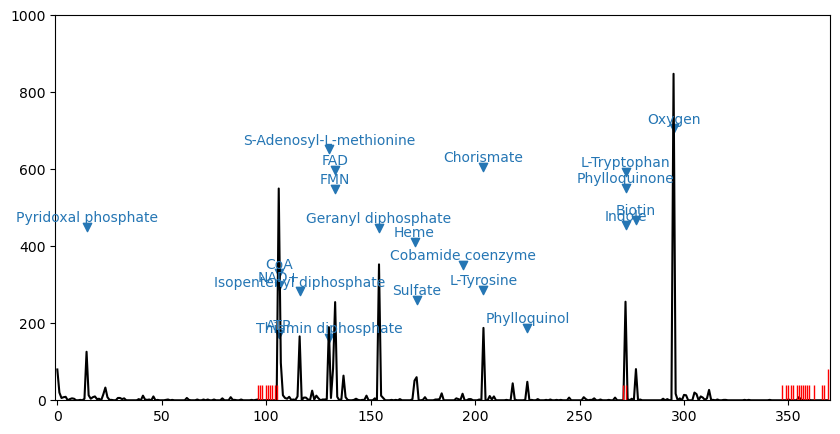

In [32]:
cpd2iter = {}
for cpd in ['C00341', 'C00463', 'C03313', 'C00032', 'C00059', 'C00251', 'C00082', 'C00078', 'C02059', 'C00120', 
          'C00018', 'C11440', 'C00002', 'C00003', 'C00010', 'C00129', 'C00068', 'C00019', 'C00016', 'C00061', 
          'C00194', 'C00007']:
    for folditer in folditer2cpd_NONE.keys():
        for c in folditer2cpd_NONE[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer

# plot line
plt.figure(figsize=(10, 5))
plt.plot(folditer2cpdNumFull_NONE.values(), color='k')

# Add cpd annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='#2576B4')
    plt.scatter(value, position - 5, color='#2576B4', marker='v')

# Add rugplots at the top
sns.rugplot(double_injection_NONE, height=0.04, color='r')  # double fold injection
sns.rugplot(triple_injection_NONE, height=0.08, color='r')  # triple fold injection

plt.xlim([-1, len(folditer2cpdNumFull_NONE.values())])
plt.ylim([0, 1000])
# plt.savefig('multi_NONE_cpds.svg', dpi=300, bbox_inches='tight')
plt.show()

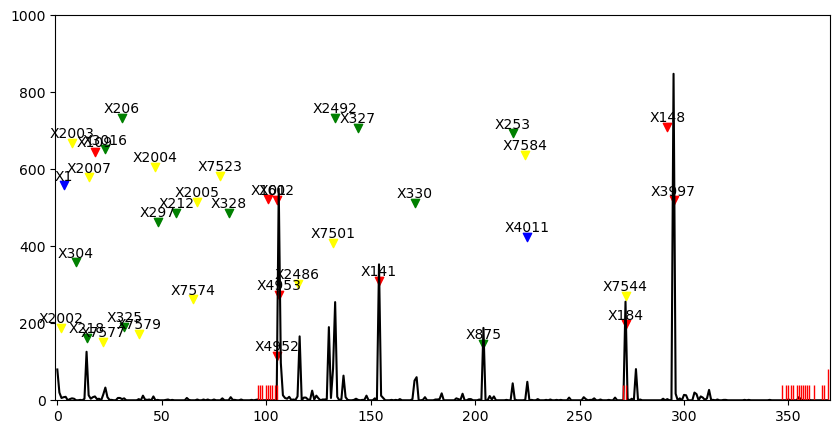

In [33]:
group12iter_NONE = {x:result_NONE.folds_folditer[x] for x in group1}

# plot line
plt.figure(figsize=(10, 5))
plt.plot(folditer2cpdNumFull_NONE.values(), color='k')

# Add lineage annotations
for key, value in group12iter_NONE.items():
    position = random.randint(100, 800)
    plt.text(value, position, 'X'+str(key), ha='center', va='bottom', color='black')
    plt.scatter(value, position-5, color=class2color[x2class[key]], marker='v')

# Add rugplots at the top
sns.rugplot(double_injection_NONE, height=0.04, color='r')  # double fold injection
sns.rugplot(triple_injection_NONE, height=0.08, color='r')  # triple fold injection

plt.xlim([-1, len(folditer2cpdNumFull_NONE.values())])
plt.ylim([0, 1000])
# plt.savefig('multi_NONE_lineages.svg', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3

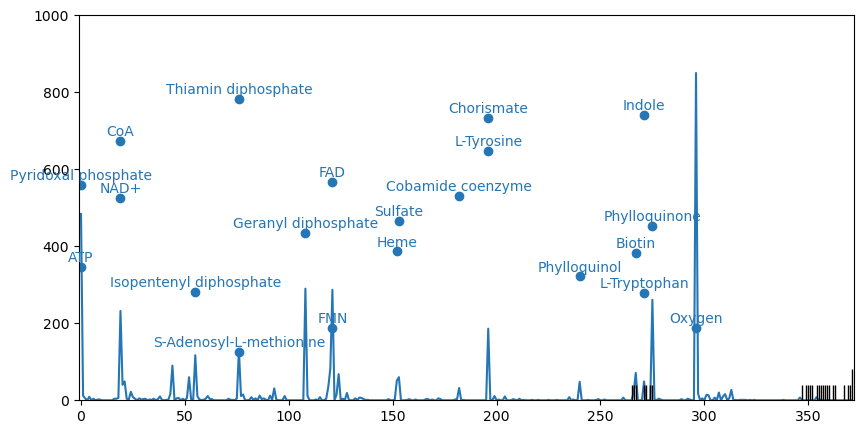

In [34]:
cpd2iter = {}
for cpd in ['C00341', 'C00463', 'C03313', 'C00032', 'C00059', 'C00251', 'C00082', 'C00078', 'C02059', 'C00120', 
          'C00018', 'C11440', 'C00002', 'C00003', 'C00010', 'C00129', 'C00068', 'C00019', 'C00016', 'C00061', 
          'C00194', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer

# plot line
plt.figure(figsize=(10, 5))
plt.plot(folditer2cpdNumFull.values(), color='#2576B4')

# Add cpd annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='#2576B4')
    plt.scatter(value, position - 5, color='#2576B4')

# Add rugplots at the top
sns.rugplot(double_injection, height=0.04, color='k')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='k')  # triple fold injection

plt.xlim([-1, len(folditer2cpdNumFull.values())])
plt.ylim([0, 1000])
# plt.savefig('Figure3A.svg', dpi=300, bbox_inches='tight')
plt.show()

### What are the cpds/reactions discovered at 'protein' discovery?

In [35]:
c = 'C00017'
for folditer in folditer2cpd.keys():
   if c in folditer2cpd[folditer]:
        print(folditer)

275


In [36]:
len(folditer2cpd[275])

261

In [37]:
# check cpds

for c in folditer2cpd[275]:
    print(c, cpd2name[c])

C15977 [Dihydrolipoyllysine-residue (2-methylpropanoyl)transferase] S-(2-methylpropanoyl)dihydrolipoyllysine
C05433 alpha-Carotene
C00088 Nitrite
C05752 Octanoyl-[acp]
C21673 N-Methylornithine lipid
C04633 (3R)-3-Hydroxypalmitoyl-[acyl-carrier protein]
C00126 Ferrocytochrome c
C12442 C-9 Reduced nonaketamide
C06412 Palmitoyl-protein
C04773 3-Hydroxy-4-hydroxymethyl-2-methylpyridine-5-carboxylate
C15814 Thiocarboxy-[sulfur-carrier protein]
C04088 Octadecanoyl-[acyl-carrier protein]
C05749 Hexanoyl-[acp]
C00906 5,6-Dihydrothymine
C16238 Lipoyl-AMP
C07044 Hydroxyurea
C05748 trans-Hex-2-enoyl-[acp]
C02059 Phylloquinone
C21437 [Sulfur-carrier protein]-Gly-Gly-L-Cys
C18327 7,9,12-Octaketide intermediate 1
C12354 3,5,7,9,11,13,15,17,19-Nonaoxo-eicosanoyl-[acp]
C01035 4-Guanidinobutanoate
C20374 Enoylglutaryl-[acp] methyl ester
C05744 Acetoacetyl-[acp]
C21313 3,6-Dimethylsalicylyl-CoA
C19871 Guanylyl molybdenum cofactor
C21357 3-Hydroxyhexadeca-4,6,8,10,12,14-hexaenoyl-[acp]
C18334 7,9,12-Deca

In [38]:
# check rns

folditer2rns = {}
for c, order in result.rns_folditer.items():
    if order not in folditer2rns.keys():
        folditer2rns[order] = [c]
    else:
        folditer2rns[order].append(c)
print(len(folditer2rns))

292


In [39]:
len(folditer2rns[275])

597

In [40]:
len(cpd2rn['C00017']), len(cpd2rn['C00229']), len(cpd2rn['C00062']), len(cpd2rn['C02059'])

(45, 91, 50, 6)

In [41]:
# could be anything using protein (C00017), acyl-carrier protein (C00229), arginine (C00062) etc.
mods_275 = set()
for rn in folditer2rns[275]:
    mods = rn2modules.get(rn, [])
    for mod in mods:
        mods_275.add(mod)
for m in mods_275:
    print(m, module2name[m])

M00418 Toluene degradation, anaerobic, toluene => benzoyl-CoA
M00883 Lipoic acid biosynthesis, animals and bacteria, octanoyl-ACP => dihydrolipoyl-H => dihydrolipoyl-E2
M00834 Calicheamicin orsellinate moiety biosynthesis, malonyl-CoA => orsellinate-ACP => 5-iodo-2,3-dimethoxyorsellinate-ACP
M00881 Lipoic acid biosynthesis, plants and bacteria, octanoyl-ACP => dihydrolipoyl-E2/H
M00882 Lipoic acid biosynthesis, eukaryotes, octanoyl-ACP => dihydrolipoyl-H
M00529 Denitrification, nitrate => nitrogen
M00307 Pyruvate oxidation, pyruvate => acetyl-CoA
M00895 Thiamine biosynthesis, prokaryotes, AIR (+ DXP/glycine) => TMP/TPP
M00595 Thiosulfate oxidation by SOX complex, thiosulfate => sulfate
M00377 Reductive acetyl-CoA pathway (Wood-Ljungdahl pathway)
M00127 Thiamine biosynthesis, prokaryotes, AIR (+ DXP/tyrosine) => TMP/TPP
M00829 3,6-Dimethylsalicylyl-CoA biosynthesis, malonyl-CoA => 6-methylsalicylate => 3,6-dimethylsalicylyl-CoA
M00083 Fatty acid biosynthesis, elongation
M00947 D-Arginin

In [42]:
# look at ACP
mods_ACP = set()
for rn in cpd2rn['C00229']:
    mods = rn2modules.get(rn, [])
    for mod in mods:
        mods_ACP.add(mod)
for m in mods_ACP:
    print(m, module2name[m])

# polyketide / antibiotics synthesis

M00778 Type II polyketide backbone biosynthesis, acyl-CoA + malonyl-CoA => polyketide
M00893 Lovastatin biosynthesis, malonyl-CoA => lovastatin acid
M00834 Calicheamicin orsellinate moiety biosynthesis, malonyl-CoA => orsellinate-ACP => 5-iodo-2,3-dimethoxyorsellinate-ACP
M00833 Calicheamicin biosynthesis, calicheamicinone => calicheamicin
M00881 Lipoic acid biosynthesis, plants and bacteria, octanoyl-ACP => dihydrolipoyl-E2/H
M00882 Lipoic acid biosynthesis, eukaryotes, octanoyl-ACP => dihydrolipoyl-H
M00883 Lipoic acid biosynthesis, animals and bacteria, octanoyl-ACP => dihydrolipoyl-H => dihydrolipoyl-E2
M00837 Prodigiosin biosynthesis, L-proline => prodigiosin
M00060 KDO2-lipid A biosynthesis, Raetz pathway, LpxL-LpxM type
M00838 Undecylprodigiosin biosynthesis, L-proline => undecylprodigiosin


# When do we see uncertainties? – single_rule & co_dependent

In [43]:
# NONE

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/folds_folditer_NONE.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/cpds_folditer_NONE.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rns_folditer_NONE.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_NONE/rules_folditer_NONE.csv', index_col=0)

# preATP

# df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
# df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
# df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
# df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

In [44]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

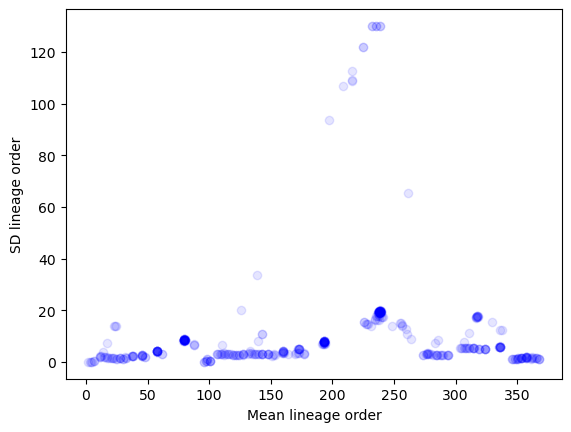

In [45]:
scatter(x2foMean, x2foStd, 'Mean lineage order', 'SD lineage order')

### define single_rule

In [46]:
fold2fo_list = []
for run in df_folds_folditer.columns:
    fold2fo = {}
    for fold, order in df_folds_folditer[run].items():
        fold2fo[fold] = order
    fold2fo_list.append(fold2fo)

In [47]:
fo2rules_list = []
for run in df_rules_folditer.columns:
    fo2rules = {}
    for c, order in df_rules_folditer[run].items():
        if order not in fo2rules.keys():
            fo2rules[order] = [c]
        else:
            fo2rules[order].append(c)
    fo2rules_list.append(fo2rules)
    
fo2ruleNum_list = []  # NOT cummulative
for run in fo2rules_list:                   
    fo2ruleNum = {key:len(values) for key, values in run.items()}
    fo2ruleNum_list.append(fo2ruleNum)

In [48]:
fold2rulesNum_list = []  # [dicts * #runs]
for i in range(0,len(df_folds_folditer.columns)):
    fold2rulesNum = {}
    
    for fold in fold2fo_list[i].keys():
        if fold not in ['fold_independent', 'spontaneous']:
            fo = fold2fo_list[i][fold]
            fold2rulesNum[fold] = fo2ruleNum_list[i][fo]  # connect fold with # new rules
    fold2rulesNum_list.append(fold2rulesNum)
    
fold2rulesNum_all = {key:[] for key in fold2rulesNum_list[0].keys()}  # empty dict
for run in fold2rulesNum_list:
    for fold, num in run.items():
        fold2rulesNum_all[fold].append(num)

In [49]:
## annotate single_rules (any)
single_rule = set()
count = 0
for x, nums in fold2rulesNum_all.items():
    if 1 in nums:  # at least one run where #new rules added == 1
#     if 1 in nums or 2 in nums or 3 in nums:  # at least one run where #new rules added <= 3
        single_rule.add(x)
        if nums.count(1)/len(nums) == 1.0:  # 100% of runs
            count+=1
print(len(single_rule))
print(count)

114
98


In [50]:
## annotate single_rules (50%)
single_rule = set()
for x, nums in fold2rulesNum_all.items():
    if nums.count(1)/len(nums) >= 0.50:  # in >=50% of runs, #new rules added == 1
    # if (nums.count(1) + nums.count(2))/len(nums) >= 0.50:  # in >=50% of runs, #new rules added < 3
        single_rule.add(x)
print(len(single_rule))

104


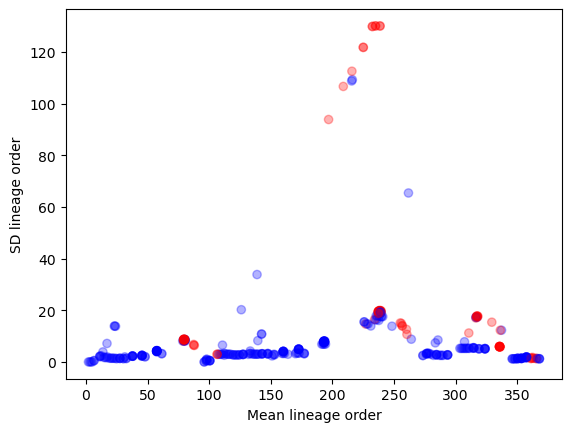

In [51]:
valid_keys, data1, data2 = todata(x2foMean, x2foStd)
colors = ['r' if key in single_rule else 'b' for key in valid_keys]

plt.scatter(data1, data2, marker='o', color=colors, alpha = 0.3, label='Data Points', zorder=2)
plt.xlabel('Mean lineage order')
plt.ylabel('SD lineage order')
# plt.savefig('scatter.png')
plt.show()

In [52]:
# 11 folds with x2foStd[x] > 30
# these are double-injection folds! (10 / 11 actually)

for x, nums in fold2rulesNum_all.items():
    if x2foStd[x] > 30:
        print(x, list(df_folds_folditer.loc[x]))

7586 [102, 106, 293, 293, 291, 105, 294, 103, 292, 105, 288, 102, 104, 108, 291, 102, 293, 103, 105, 107, 292, 106, 291, 106, 104, 298, 292, 105, 293, 294, 103, 106, 104, 102, 299, 105, 106, 106, 294, 290, 293, 293, 108, 104, 294, 102, 290, 104, 102, 288, 102, 292, 102, 102, 292, 102, 102, 294, 293, 102, 296, 104, 292, 290, 102, 290, 102, 103, 103, 103, 288, 104, 291, 294, 102, 293, 106, 295, 105, 296, 294, 106, 295, 107, 106, 292, 103, 291, 102, 107, 293, 103, 103, 104, 289, 108, 288, 103, 104, 291, 105, 102, 102, 290, 292, 106, 290, 107, 102, 104, 294, 294, 103, 102, 294, 291, 103, 108, 106, 104, 295, 105, 290, 103, 293, 295, 102, 103, 103, 292, 291, 107, 296, 104, 292, 103, 292, 291, 291, 109, 104, 105, 292, 106, 106, 106, 295, 102, 108, 108, 293, 293, 109, 292, 295, 292, 104, 290, 103, 288, 104, 291, 294, 296, 103, 293, 103, 291, 294, 104, 105, 291, 292, 108, 102, 291, 104, 292, 292, 290, 102, 290, 103, 291, 103, 102, 291, 292, 293, 105, 103, 109, 104, 106, 104, 102, 103, 106, 290,

In [53]:
# multi-injection in ANY runs

multiples = set()
for run in fold2fo_list:
    
    fo2folds = {}
    for x, fo in run.items():
        if fo not in fo2folds:
            fo2folds[fo] = [x]
        else:
            fo2folds[fo].append(x)
    
    for fo, folds in fo2folds.items():
        if len(folds) > 1:
            multiples = multiples | set(folds)
print(len(multiples))

63


In [54]:
# multi-injection in ≥ 50% of runs

multiples = []
for run in fold2fo_list:
    
    fo2folds = {}
    for x, fo in run.items():
        if fo not in fo2folds:
            fo2folds[fo] = [x]
        else:
            fo2folds[fo].append(x)
    
    for fo, folds in fo2folds.items():
        if len(folds) > 1:
            multiples.append(folds)

fold2multiple_count = {}
for folds in multiples:
    for fold in folds:
        if fold not in fold2multiple_count:
            fold2multiple_count[fold] = 1
        else:
            fold2multiple_count[fold] += 1
multiples = set([k for k,v in fold2multiple_count.items() if v >= 500])
len(multiples)

55

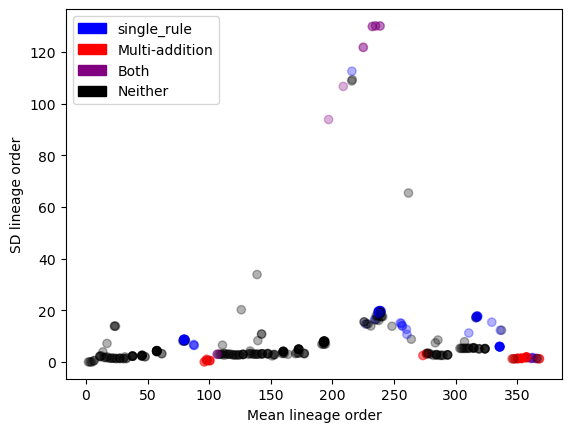

In [55]:
valid_keys, data1, data2 = todata(x2foMean, x2foStd)

# Define colors based on boolean conditions
colors = [
    'blue' if (key in single_rule and key not in multiples) else 
    'red' if (key in multiples and key not in single_rule) else 
    'purple' if (key in multiples and key in single_rule) else 
    'black' 
    for key in valid_keys
]

# Create scatter plot
plt.scatter(data1, data2, marker='o', color=colors, alpha=0.3, label='Data Points', zorder=2)
plt.xlabel('Mean lineage order')
plt.ylabel('SD lineage order')

# Create legend manually
legend_patches = [
    mpatches.Patch(color='blue', label='single_rule'),
    mpatches.Patch(color='red', label='Multi-addition'),
    mpatches.Patch(color='purple', label='Both'),
    mpatches.Patch(color='black', label='Neither')
]
plt.legend(handles=legend_patches, loc='upper left')

# Save and show the plot
# plt.savefig('foMean_fo_vs_foStd_NONE_50_50.svg')
plt.show()

# "burst analysis"
Average #cpd discovered as a result of each fold injection => fold2cpdNum(Ave)

In [56]:
# preATP

folds = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
cpds = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)

In [57]:
# map folditer2cpdsNum

i2cNum_1000runs = {}
for run in cpds.columns:
    i2c = {}
    for c, i in cpds[run].items():
        if i not in i2c.keys():
            i2c[i] = [c]
        else:
            i2c[i].append(c)
    i2cNum_1000runs[run] = {i:len(c) for i, c in i2c.items()}

In [58]:
fold2cpdNum_1000runs = {}
for run in folds.columns:
    fold2cpdNum = {}
    for fold, i in folds[run].items():  # fold2folditer
        fold2cpdNum[fold] = i2cNum_1000runs[run].get(i, 0)
    fold2cpdNum_1000runs[run] = fold2cpdNum

In [59]:
# empty dict with folds as keys
fold2cpdNum = {fold:[] for fold in folds.index}

for run in fold2cpdNum_1000runs:
    for fold, num in fold2cpdNum_1000runs[run].items():
        fold2cpdNum[fold].append(num)

for fold in fold2cpdNum.keys():
    fold2cpdNum[fold] = [np.mean(fold2cpdNum[fold]), np.std(fold2cpdNum[fold])]

fold2cpdNumMean = {fold:num[0] for fold, num in fold2cpdNum.items()}
fold2cpdNumStd = {fold:num[1] for fold, num in fold2cpdNum.items()}

In [60]:
burst_folds = {}
for key, value in fold2cpdNumMean.items():
    if value > 50 and key != 'fold_independent':
        burst_folds[key] = value
burst_folds

{'2005': 232.0,
 '7581': 90.0,
 '3016': 60.0,
 '103': 117.0,
 '323': 129.994,
 '141': 289.743,
 '7501': 83.018,
 '2492': 291.226,
 '266': 68.0,
 '296': 60.0,
 '875': 201.49,
 '4033': 71.0,
 '4052': 71.0,
 '602': 261.0,
 '4953': 261.0,
 '3997': 850.0}

## burst size vs. reaction rule count

In [61]:
x2rulesNum_scope = csv2dict('../data/assets/xgroup2/xgroup2rulesNum_scope.csv')
len(x2rulesNum_scope)

396

In [62]:
def safeLog10(data_dict, small_constant=10**-0.00001):
    log10_dict = {}
    for key, value in data_dict.items():
        if value == 0:
            log10_value = 0  # log10 of small constant if value is zero or negative
        elif value < 1:
            log10_value = round(value)
        else:
            log10_value = np.log10(value)
        log10_dict[key] = log10_value
    return log10_dict

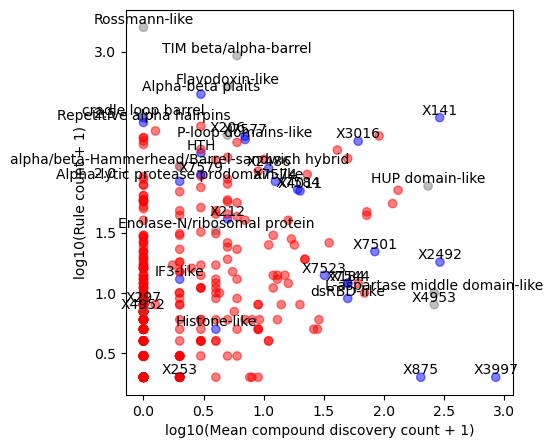

In [63]:
plt.figure(figsize=(5, 5))
# dict1 = fold2cpdNumMean
# dict1 = safeLog10(fold2cpdNumMean)
# dict2 = safeLog10(x2rulesNum_scope)

dict1 = {k:np.log10(1 + v) for k,v in fold2cpdNumMean.items()}
dict2 = {k:np.log10(1 + v) for k,v in x2rulesNum_scope.items()}


valid_keys, data1, data2 = todata(dict1, dict2)

# plt.errorbar(np.log10(data1), np.log10(data2_no_zeros), yerr=np.log10(list(fold2cpdNumStd.values())[2:]), fmt='o', color='b', alpha = 0.5, capsize=5)
colors = ['gray' if key in first10 else ('b' if key in group1 else 'r') for key in valid_keys]
plt.scatter(data1, data2, color=colors, alpha = 0.5)


# Add annotations
# for key, value in burst_folds.items():
#     plt.text(np.log10(value + 1), np.log10(x2rulesNum_scope[key] + 1), 'X'+str(key), ha='center', va='bottom', color='blue')
for fold in group1:
    plt.text(dict1[fold], dict2[fold], f"{x2name.get(fold, 'X'+str(fold))}", ha='center', va='bottom', color='black')

plt.xlabel('log10(Mean compound discovery count + 1)')
plt.ylabel('log10(Rule count + 1)')
# plt.savefig('burst_analysis_rulesNum_loglog_preATP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
fold2cpdNumMean

{'fold_independent': 484.0,
 'spontaneous': 12.0,
 '2002': 5.0,
 '2006': 0.0,
 '2484': 9.0,
 '2003': 0.0,
 '2007': 4.0,
 '1': 0.0,
 '10': 2.0,
 '304': 2.0,
 '7527': 0.0,
 '246': 0.0,
 '805': 0.0,
 '11': 0.0,
 '12': 0.0,
 '206': 4.0,
 '221': 4.0,
 '7525': 0.0,
 '2004': 6.0,
 '2005': 232.0,
 '236': 40.0,
 '7524': 49.0,
 '4002': 4.0,
 '279': 2.0,
 '298': 22.0,
 '129': 8.0,
 '7510': 4.0,
 '159': 0.0,
 '5': 2.0,
 '2011': 5.0,
 '218': 3.0,
 '131': 4.0,
 '7579': 2.0,
 '2487': 1.0,
 '210': 0.0,
 '109': 0.0,
 '7542': 3.0,
 '7531': 4.0,
 '7518': 0.0,
 '325': 1.0,
 '2486': 10.0,
 '301': 1.0,
 '7581': 90.0,
 '223': 1.0,
 '281': 16.0,
 '7504': 0.0,
 '7515': 0.0,
 '222': 5.0,
 '212': 4.0,
 '213': 6.0,
 '7572': 0.0,
 '7512': 3.0,
 '7577': 6.0,
 '3016': 60.0,
 '4004': 2.0,
 '103': 117.0,
 '3692': 11.0,
 '4021': 2.0,
 '7516': 4.0,
 '208': 11.0,
 '328': 1.0,
 '247': 1.0,
 '286': 3.0,
 '65': 3.0,
 '7573': 0.0,
 '7528': 0.0,
 '331': 0.0,
 '7517': 0.0,
 '180': 0.0,
 '219': 4.0,
 '5104': 0.0,
 '282': 0.0,
 

In [65]:
for k,v in dict1.items():
    print(k,v, fold2cpdNumMean[k])

fold_independent 2.6857417386022635 484.0
spontaneous 1.1139433523068367 12.0
2002 0.7781512503836436 5.0
2006 0.0 0.0
2484 1.0 9.0
2003 0.0 0.0
2007 0.6989700043360189 4.0
1 0.0 0.0
10 0.47712125471966244 2.0
304 0.47712125471966244 2.0
7527 0.0 0.0
246 0.0 0.0
805 0.0 0.0
11 0.0 0.0
12 0.0 0.0
206 0.6989700043360189 4.0
221 0.6989700043360189 4.0
7525 0.0 0.0
2004 0.8450980400142568 6.0
2005 2.367355921026019 232.0
236 1.6127838567197355 40.0
7524 1.6989700043360187 49.0
4002 0.6989700043360189 4.0
279 0.47712125471966244 2.0
298 1.3617278360175928 22.0
129 0.9542425094393249 8.0
7510 0.6989700043360189 4.0
159 0.0 0.0
5 0.47712125471966244 2.0
2011 0.7781512503836436 5.0
218 0.6020599913279624 3.0
131 0.6989700043360189 4.0
7579 0.47712125471966244 2.0
2487 0.3010299956639812 1.0
210 0.0 0.0
109 0.0 0.0
7542 0.6020599913279624 3.0
7531 0.6989700043360189 4.0
7518 0.0 0.0
325 0.3010299956639812 1.0
2486 1.0413926851582251 10.0
301 0.3010299956639812 1.0
7581 1.9590413923210936 90.0
2

In [66]:
for k,v in dict2.items():
    print(k,v, x2rulesNum_scope[k])

2002 2.967079734144497 926
2003 3.2024883170600935 1593
298 1.9822712330395684 95
2484 2.1072099696478683 127
7560 0.6989700043360189 4
304 2.6473829701146196 443
129 2.0086001717619175 101
5 1.8750612633917 74
279 1.7075701760979363 50
7524 2.113943352306837 129
2486 2.03342375548695 107
11 2.2600713879850747 181
7531 1.380211241711606 23
1 2.45178643552429 282
3001 0.3010299956639812 1
208 1.4771212547196624 29
286 1.0413926851582251 10
2007 2.709269960975831 511
7579 1.9822712330395684 95
206 2.307496037913213 202
2006 2.285557309007774 192
212 1.6127838567197355 40
328 1.1139433523068367 12
4002 1.9030899869919435 79
2004 2.271841606536499 186
7523 1.146128035678238 13
164 1.0 9
3117 0.47712125471966244 2
231 1.7558748556724915 56
213 1.6020599913279623 39
602 1.0 9
4953 0.9030899869919435 7
2005 1.8864907251724818 76
253 0.3010299956639812 1
3699 0.9030899869919435 7
10 2.380211241711606 239
2011 1.7481880270062005 55
101 2.161368002234975 144
4011 1.845098040014257 69
7584 1.8573

## check burst lineages

In [67]:
# X875 (chorismate synth)

x2rn['875'], [cpd2name[v] for v in rn2cpds[x2rn['875'][0]]]

(['R01714_v1'],
 ['Orthophosphate',
  'Chorismate',
  '5-O-(1-Carboxyvinyl)-3-phosphoshikimate',
  'FMN'])

In [68]:
# X2492 (Flavin)
result.folds_cumiter['2492']

347

In [69]:
[(rn, result.rns_cumiter.get(rn, 'not in scope'), rn2rules[rn]) for rn in x2rn['2492']]

[('R04606', 'not in scope', {frozenset({'2003', '2492'})}),
 ('R03458', 348, {frozenset({'7501'}), frozenset({'2492', '7501'})}),
 ('R09377', 349, {frozenset({'2492', '304'})}),
 ('R01127', 81, {frozenset({'2492', '7543'}), frozenset({'210'})}),
 ('R04325',
  336,
  {frozenset({'7571'}),
   frozenset({'2492', '7571'}),
   frozenset({'2003', '206', '301', '304', '325', '7571'})}),
 ('R04560', 347, {frozenset({'2492', '7571'}), frozenset({'2492', '7543'})}),
 ('R01004', 'not in scope', {frozenset({'2492'})}),
 ('R02922', 672, {frozenset({'2002'}), frozenset({'2492'})}),
 ('R04326',
  336,
  {frozenset({'7571'}),
   frozenset({'2492', '7571'}),
   frozenset({'2003', '206', '301', '304', '325', '7571'})}),
 ('R02418',
  'not in scope',
  {frozenset({'219', '377'}),
   frozenset({'219', '376'}),
   frozenset({'108', '219', '221', '277', '4309'}),
   frozenset({'219', '4'}),
   frozenset({'221', '4309'}),
   frozenset({'219'}),
   frozenset({'103', '219', '3656'}),
   frozenset({'11', '219',

In [70]:
for rn in ['R04560', 'R04325', 'R03459_v1', 'R01676_v1']:
    print(rn)
    print([(v, cpd2name[v], result.cpds_cumiter[v]) for v in rn2cpds[rn]])

R04560
[('C04734', "1-(5'-Phosphoribosyl)-5-formamido-4-imidazolecarboxamide", 0), ('C04677', "1-(5'-Phosphoribosyl)-5-amino-4-imidazolecarboxamide", 0), ('C00101', 'Tetrahydrofolate', 335), ('C00234', '10-Formyltetrahydrofolate', 336)]
R04325
[('C03838', "5'-Phosphoribosylglycinamide", 0), ('C00101', 'Tetrahydrofolate', 335), ('C00234', '10-Formyltetrahydrofolate', 336), ('C04376', "5'-Phosphoribosyl-N-formylglycinamide", 0)]
R03459_v1
[('C00014', 'Ammonia', 0), ('Z00054', 'Zinc', 0), ('C01268', "5-Amino-6-(5'-phosphoribosylamino)uracil", 347), ('C01304', '2,5-Diamino-6-(5-phospho-D-ribosylamino)pyrimidin-4(3H)-one', 325), ('C00001', 'H2O', 0)]
R01676_v1
[('C00242', 'Guanine', 33), ('C00014', 'Ammonia', 0), ('Z00054', 'Zinc', 0), ('C00001', 'H2O', 0), ('C00385', 'Xanthine', 32)]


In [71]:
# R03459_v1 makes 'C01268', riboflavin precursor!

In [72]:
# X141 (Geranyl diphosphate)

result.folds_cumiter['141']

301

In [73]:
[(rn, result.rns_cumiter.get(rn, 'not in scope'), rn2rules[rn]) for rn in x2rn['141'] if result.rns_cumiter.get(rn, 'not in scope') == 301]

[('R01658_v1', 301, {frozenset({'141'})}),
 ('R08199_v1', 301, {frozenset({'109', '141'})}),
 ('R08199_v2', 301, {frozenset({'109', '141'})}),
 ('R01658_v2', 301, {frozenset({'141'})})]

In [74]:
for rn in ['R01658_v1', 'R01658_v2', 'R08199_v1', 'R08199_v2']:
    print(rn)
    print([(v, cpd2name[v], result.cpds_cumiter[v]) for v in rn2cpds[rn]])

R01658_v1
[('C00013', 'Diphosphate', 0), ('Z00030', 'Mn', 0), ('C00235', 'Dimethylallyl diphosphate', 287), ('C00341', 'Geranyl diphosphate', 301), ('C00129', 'Isopentenyl diphosphate', 163)]
R01658_v2
[('C00013', 'Diphosphate', 0), ('C00235', 'Dimethylallyl diphosphate', 287), ('Z00029', 'Mg', 0), ('C00341', 'Geranyl diphosphate', 301), ('C00129', 'Isopentenyl diphosphate', 163)]
R08199_v1
[('C16521', 'Isoprene', 301), ('C00235', 'Dimethylallyl diphosphate', 287), ('C00013', 'Diphosphate', 0), ('Z00030', 'Mn', 0)]
R08199_v2
[('C16521', 'Isoprene', 301), ('Z00029', 'Mg', 0), ('C00235', 'Dimethylallyl diphosphate', 287), ('C00013', 'Diphosphate', 0)]


In [75]:
# HUP (X2005): NAD, CoA

result.folds_cumiter['2005']

29

In [76]:
result.cpds_cumiter['C00003'], result.cpds_folditer['C00003']

(29, 19)

In [77]:
result.cpds_cumiter['C00010'], result.cpds_folditer['C00010']

(41, 19)

In [78]:
[(rn, result.rns_cumiter.get(rn, 'not in scope'), rn2rules[rn]) for rn in x2rn['2005'] if result.rns_cumiter.get(rn, 'not in scope') == 29]

[('R05646', 29, {frozenset({'2005'})}),
 ('R00189', 29, {frozenset({'2005'})}),
 ('R00257', 29, {frozenset({'2005', '246'})}),
 ('R12059', 29, {frozenset({'2005'})}),
 ('R00578', 29, {frozenset({'2005'})}),
 ('R03005_v4', 29, {frozenset({'2005'})}),
 ('R00137_v3', 29, {frozenset({'2005'}), frozenset({'2005', '221'})}),
 ('R00661_v1', 29, {frozenset({'2002', '2005'})}),
 ('R03005_v1', 29, {frozenset({'2005'})}),
 ('R00137_v2', 29, {frozenset({'2005'}), frozenset({'2005', '221'})}),
 ('R00137_v4', 29, {frozenset({'2005'}), frozenset({'2005', '221'})}),
 ('R03005_v3', 29, {frozenset({'2005'})}),
 ('R03005_v2', 29, {frozenset({'2005'})}),
 ('R00137_v1', 29, {frozenset({'2005'}), frozenset({'2005', '221'})})]

In [79]:
for rn in ['R05646', 'R00189', 'R00257', 'R12059', 'R00578', 'R03005_v4','R00137_v3','R00661_v1','R03005_v1','R00137_v2','R00137_v4','R03005_v3','R03005_v2','R00137_v1']:
    print(rn)
    print([(v, cpd2name[v], result.cpds_cumiter[v]) for v in rn2cpds[rn]])

R05646
[('C00008', 'ADP', 0), ('C00002', 'ATP', 0), ('C07836', 'D-glycero-beta-D-manno-Heptose 7-phosphate', 0), ('C11472', 'D-glycero-beta-D-manno-Heptose 1,7-bisphosphate', 29)]
R00189
[('C00013', 'Diphosphate', 0), ('C00020', 'AMP', 0), ('C00857', 'Deamino-NAD+', 0), ('C00014', 'Ammonia', 0), ('C00003', 'NAD+', 29), ('C00002', 'ATP', 0)]
R00257
[('C00013', 'Diphosphate', 0), ('C00020', 'AMP', 0), ('C00857', 'Deamino-NAD+', 0), ('C00001', 'H2O', 0), ('C00064', 'L-Glutamine', 0), ('C00025', 'L-Glutamate', 0), ('C00003', 'NAD+', 29), ('C00002', 'ATP', 0)]
R12059
[('C00013', 'Diphosphate', 0), ('C00002', 'ATP', 0), ('C21851', 'Pyridinium-3,5-biscarboxylic acid mononucleotide', 10), ('C21877', '5-Carboxy-1-(5-O-phospho-beta-D-ribofuranosyl)pyridin-1-ium-3-carbonyl adenylate', 29)]
R00578
[('C00152', 'L-Asparagine', 0), ('C00013', 'Diphosphate', 0), ('C00020', 'AMP', 0), ('C00001', 'H2O', 0), ('C00064', 'L-Glutamine', 0), ('C00049', 'L-Aspartate', 0), ('C00025', 'L-Glutamate', 0), ('C0000